# QTCAD M17 FD-SOI SET — Result Analysis (심화판 v2)

Practical Application "FD-SOI SET" — KLayout 없이 Builder로 직접 생성한 FD-SOI 레이아웃
(채널 + 2개 양자점 영역: SET용 QD1, 큐비트용 QD2 + 5개 게이트 B1/P1/B2/P2/B3)에서,
(1) 선형 Poisson으로 전체 소자 정전위를 구하고, (2) SET 영역에서 **자기무결
Schrödinger-Poisson**으로 N=12~14 전자 각각의 many-body 바닥상태 에너지를 구해
**Coulomb peak(화학퍼텐셜 vs 게이트전압)** 를 재현하고, (3) 이웃한 큐비트 양자점의
전하 상태(0개/1개)가 SET의 Coulomb peak 위치를 얼마나 이동시키는지(전하 검출,
charge sensing) 확인합니다.

**v2에서 추가된 것 (v1 대비)**: v1은 로그 텍스트 regex 파싱과 일부 요약 수치만 다뤄
시뮬레이션이 실제로 저장한 원시 데이터(`energies.txt`, `population.txt`, `mu.txt`, 6개
지점 각각의 파동함수/전하밀도 slice 이미지 전체)를 거의 쓰지 않았습니다. v2는 **저장된
모든 output 파일을 직접 로드**해서: 6개(Coulomb peak) + 4개(전하검출) 지점 전체의
10-레벨 에너지 스펙트럼과 점유율(population factor)을 표/그래프로 전부 제시하고,
각 지점의 파동함수·전하밀도 slice 이미지를 전부 그리드로 보여주며, lever arm/addition
energy/capacitance를 저장된 `lever_arm.txt`뿐 아니라 raw `mu.txt`에서 **직접 재적합**해
교차검증합니다.

**이 노트북에서 실제로 수행한 분석 (요약)**
- Builder 마스크 폴리곤 좌표(순수 Python `Polygon.box()` 호출)를 그대로 재현한 정확한
  top-down 스케매틱 + z-스택 구조 (0절)
- 선형 Poisson 적응정제 이력 + 전도대 단면 재현 (1절)
- **6개 지점(N=12,13,14 × V_SET=1.25,1.20V) 전체의 10-레벨 에너지 스펙트럼 + 점유율**을
  `energies.txt`/`population.txt`에서 직접 로드해 전부 시각화 (2절)
- `mu.txt`의 raw 화학퍼텐셜 4개 값을 직접 선형피팅해 lever arm/Coulomb peak 위치/addition
  energy/커패시턴스를 **독립적으로 재계산**하고 저장된 `lever_arm.txt`와 교차검증 (2절)
- 6개 지점 전체의 파동함수(`wf_*_slice.png`)·전하밀도(`rho_*_slice.png`) slice를 그리드로
  전부 표시 (2절)
- 큐비트 dot 점유 여부에 따른 SET 쪽 4개 지점(N=12,13 × V_SET 2개) 전체 에너지/점유율/mu를
  동일하게 로드·재적합해 peak shift를 독립적으로 재계산 (3절)
- 미팅 질문("센서 dot 감도를 시뮬레이션으로 설계할 가치가 있는가")에 수치 근거로 답 (4절)

---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼**: Practical Application: FD-SOI SET (Part 1~4)
  https://docs.nanoacademic.com/qtcad/practical_application/FDSOI/FDSOI_practical_application/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `1-fdsoi_builder.py`, `2-linear_poisson.py`, `3-coulomb_peaks.py`,
  `4-charge_detection.py`, `chemical_potential.py`, `double_dot_fdsoi.py`
  (전부 M17/Reference에 복사)
---

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M17. FD-SOI SET\Reference`

목차:
0. 소자 스케매틱(Builder 마스크 좌표 그대로) + z-스택 + 파라미터 선택 의도
1. 선형 Poisson 적응정제 + 전도대 단면
2. Coulomb Peak — 전체 6개 지점 에너지/점유율/파동함수/밀도 + 독립 lever-arm 재적합
3. 전하 검출(Charge Sensing) — 전체 4개 지점 데이터 + 독립 peak-shift 재계산
4. 최종 요약 + 미팅 질문에 대한 답


## 0. 소자 스케매틱 + z-스택 + 파라미터 선택 의도

`1-fdsoi_builder.py`에 정의된 **순수 Python 좌표 공식**(`Polygon.box(width, length,
name=...).centered().translated(...)`)을 그대로 재계산해서 그린 정확한 top-down
스케매틱입니다 (마스크 좌표가 이미 해석적 함수로 주어져 있어 M12처럼 별도 레이아웃
파일 파싱이 필요 없습니다).

In [1]:
# [동작] 기본 패키지 및 경로 설정
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
from scipy.optimize import curve_fit
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M17. FD-SOI SET\Reference"
)
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = OUTPUT_DIR / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

ct_e = 1.602176634e-19

print("BASE_DIR  :", BASE_DIR)
assert OUTPUT_DIR.exists()
print("[OK] 기본 경로 확인 완료")


BASE_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M17. FD-SOI SET\Reference
[OK] 기본 경로 확인 완료


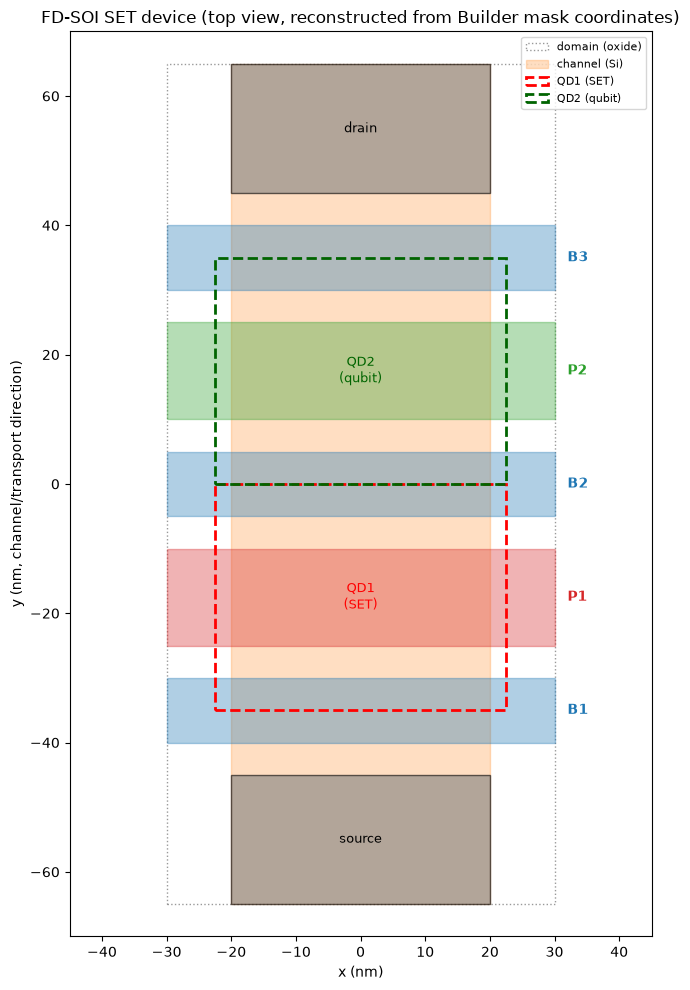

domain: 60 x 130 nm | channel width: 40 nm | QD1(SET) center y=-17.5nm, QD2(qubit) center y=17.5nm

[구조 해석] P1 아래 QD1이 SET(전하 센서), P2 아래 QD2가 큐비트 dot입니다. 둘 사이 B2가 두 dot을 분리하는 중앙 배리어, B1/B3가 소스/드레인 쪽 배리어입니다. QD1과 QD2가 B2 하나 간격(10 nm + 2*pitch)만큼 떨어져 있어, 3절에서 QD2에 전자가 들어오면 QD1의 Coulomb peak가 정전용량적으로 결합되어 이동합니다 — 이것이 전하 센서의 작동 원리.


In [2]:
# [실험] 소자 스케매틱 재현 (1-fdsoi_builder.py 27-42행의 치수/좌표 공식 그대로)
char_len = 4
domain_w, domain_l = 60, 130
channel_w = 40
plunger_w, barrier_w = 15, 10
source_drain_w = 20
pitch = 5
QD_w = plunger_w + barrier_w + 2 * pitch
box_thick, channel_thick, EOT_thick = 10, 10, 2

fig, ax = plt.subplots(figsize=(7, 10))
ax.add_patch(mpatches.Rectangle((-domain_w/2, -domain_l/2), domain_w, domain_l,
                                 fc="none", ec="0.6", ls=":", label="domain (oxide)"))
ax.add_patch(mpatches.Rectangle((-channel_w/2, -domain_l/2), channel_w, domain_l,
                                 fc="tab:orange", alpha=0.25, ec="tab:orange", label="channel (Si)"))

def centered_box(w, l, dy, color, label, alpha=0.6):
    ax.add_patch(mpatches.Rectangle((-w/2, dy - l/2), w, l, fc=color, alpha=alpha, ec="k"))
    return dy

source_y = -(domain_l - source_drain_w) / 2
drain_y = (domain_l - source_drain_w) / 2
centered_box(channel_w, source_drain_w, source_y, "tab:gray", "source")
centered_box(channel_w, source_drain_w, drain_y, "tab:gray", "drain")
ax.text(0, source_y, "source", ha="center", va="center", fontsize=9)
ax.text(0, drain_y, "drain", ha="center", va="center", fontsize=9)

B1_y = -(barrier_w + 2*pitch + plunger_w)
P1_y = -(barrier_w/2 + pitch + plunger_w/2)
B2_y = 0
P2_y = (barrier_w/2 + pitch + plunger_w/2)
B3_y = (barrier_w + 2*pitch + plunger_w)
gates = [("B1", B1_y, barrier_w, "tab:blue"), ("P1", P1_y, plunger_w, "tab:red"),
         ("B2", B2_y, barrier_w, "tab:blue"), ("P2", P2_y, plunger_w, "tab:green"),
         ("B3", B3_y, barrier_w, "tab:blue")]
for name, y0, w, c in gates:
    ax.add_patch(mpatches.Rectangle((-domain_w/2, y0 - w/2), domain_w, w, fc=c, alpha=0.35, ec=c))
    ax.text(domain_w/2 + 2, y0, name, va="center", fontsize=10, fontweight="bold", color=c)

QD1_y = P1_y  # SET dot, under P1
QD2_y = P2_y  # Qubit dot, under P2
ax.add_patch(mpatches.Rectangle((-(channel_w+pitch)/2, QD1_y - QD_w/2), channel_w+pitch, QD_w,
                                 fc="none", ec="red", ls="--", lw=2, label="QD1 (SET)"))
ax.add_patch(mpatches.Rectangle((-(channel_w+pitch)/2, QD2_y - QD_w/2), channel_w+pitch, QD_w,
                                 fc="none", ec="darkgreen", ls="--", lw=2, label="QD2 (qubit)"))
ax.text(0, QD1_y, "QD1\n(SET)", ha="center", va="center", fontsize=9, color="red")
ax.text(0, QD2_y, "QD2\n(qubit)", ha="center", va="center", fontsize=9, color="darkgreen")

ax.set_xlim(-domain_w/2 - 15, domain_w/2 + 15); ax.set_ylim(-domain_l/2 - 5, domain_l/2 + 5)
ax.set_aspect("equal")
ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm, channel/transport direction)")
ax.set_title("FD-SOI SET device (top view, reconstructed from Builder mask coordinates)")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device_schematic_top_view.png", dpi=150)
plt.show()

print(f"domain: {domain_w} x {domain_l} nm | channel width: {channel_w} nm | "
      f"QD1(SET) center y={QD1_y:.1f}nm, QD2(qubit) center y={QD2_y:.1f}nm")
print(
    "\n[구조 해석] P1 아래 QD1이 SET(전하 센서), P2 아래 QD2가 큐비트 dot입니다. 둘 사이 "
    "B2가 두 dot을 분리하는 중앙 배리어, B1/B3가 소스/드레인 쪽 배리어입니다. QD1과 QD2가 "
    f"B2 하나 간격(10 nm + 2*pitch)만큼 떨어져 있어, 3절에서 QD2에 전자가 들어오면 QD1의 "
    "Coulomb peak가 정전용량적으로 결합되어 이동합니다 — 이것이 전하 센서의 작동 원리."
)


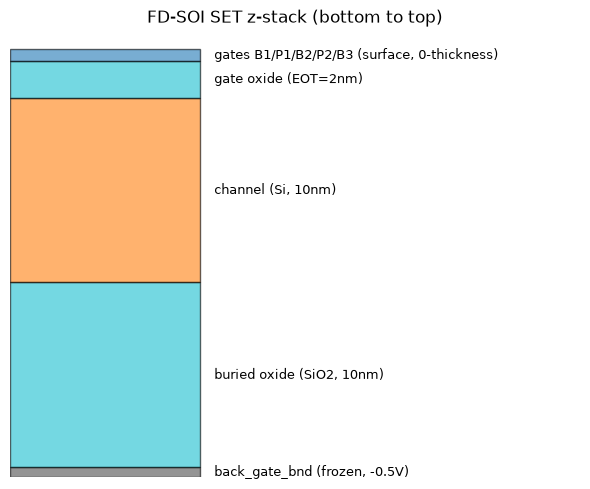

In [3]:
# [실험] z-스택 구조 (1-fdsoi_builder.py 39-42행 두께 + Builder 파이프라인 순서)
layers = [
    ("back_gate_bnd (frozen, -0.5V)", 0, 0.5, "0.3"),
    (f"buried oxide (SiO2, {box_thick}nm)", 0.5, box_thick, "tab:cyan"),
    (f"channel (Si, {channel_thick}nm)", 0.5+box_thick, channel_thick, "tab:orange"),
    (f"gate oxide (EOT={EOT_thick}nm)", 0.5+box_thick+channel_thick, EOT_thick, "tab:cyan"),
    ("gates B1/P1/B2/P2/B3 (surface, 0-thickness)",
     0.5+box_thick+channel_thick+EOT_thick, 0.6, "tab:blue"),
]
fig, ax = plt.subplots(figsize=(6, 5))
y = 0
for name, _, thick, color in layers:
    ax.add_patch(mpatches.Rectangle((0, y), 4, thick, fc=color, alpha=0.6, ec="k"))
    ax.text(4.3, y + thick/2, name, va="center", fontsize=9)
    y += thick
ax.set_xlim(0, 12); ax.set_ylim(0, y + 1)
ax.axis("off")
ax.set_title("FD-SOI SET z-stack (bottom to top)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device_zstack.png", dpi=150)
plt.show()


In [4]:
# [점검] 게이트 전압 선택 의도 요약표
param_intent = pd.DataFrame([
    {"parameter": "char_len=4nm", "intent": "M03/M06 dqdfdsoi 메시(기본 요소크기 더 큼)보다 "
     "조밀한 기본 메시 — Builder가 처음부터 전체 소자를 비교적 세밀하게 짜도록."},
    {"parameter": "QD_w = plunger_w+barrier_w+2*pitch = 40nm",
     "intent": "dot 영역이 인접 배리어 절반씩까지 포함하도록 — 양자점 포텐셜이 플런저 "
               "게이트 바로 아래뿐 아니라 배리어 쪽 일부까지 걸쳐 있다는 물리적 사실 반영."},
    {"parameter": "V_set=1.25V, V_qubit=0.75V (double_dot_fdsoi.py 기본값)",
     "intent": "SET이 큐비트보다 높은 전압으로 더 깊게 비워/채워지도록 설계 — SET은 "
               "여러 전자를 번갈아 넣고 빼며 Coulomb peak를 스캔해야 하므로 동작 범위가 "
               "더 넓어야 함."},
    {"parameter": "Nmin=12, Nmax=14 (script 3) / Nmax=13 (script 4)",
     "intent": "이미 어느 정도 차 있는 SET(12개 이상)에서 1~2개를 더 넣으며 Coulomb peak "
               "2~3개를 관찰 — 0개부터 채우면 계산량이 커지므로, 이미 알려진 동작점 근방만 "
               "스캔하는 실무적 선택."},
    {"parameter": "sp_params.bound_state_charges_only=True, sc_method='underrelax'",
     "intent": "속박상태 전하만 자기무결 루프에 포함(연속상태 무시로 수렴 안정화), "
               "underrelax + adaptive_linear 믹싱(mixing_param=0.1)으로 느리지만 안정적인 "
               "수렴 — maxiter=2000까지 허용한 것은 이 소자의 수렴이 쉽지 않음을 시사."},
])
display(param_intent)
param_intent.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


,parameter,intent
0,char_len=4nm,M03/M06 dqdfdsoi 메시(기본 요소크기 더 큼)보다 조밀한 기본 메시 —...
1,QD_w = plunger_w+barrier_w+2*pitch = 40nm,dot 영역이 인접 배리어 절반씩까지 포함하도록 — 양자점 포텐셜이 플런저 게이트 ...
2,"V_set=1.25V, V_qubit=0.75V (double_dot_fdsoi.p...",SET이 큐비트보다 높은 전압으로 더 깊게 비워/채워지도록 설계 — SET은 여러 ...
3,"Nmin=12, Nmax=14 (script 3) / Nmax=13 (script 4)",이미 어느 정도 차 있는 SET(12개 이상)에서 1~2개를 더 넣으며 Coulom...
4,"sp_params.bound_state_charges_only=True, sc_me...","속박상태 전하만 자기무결 루프에 포함(연속상태 무시로 수렴 안정화), underre..."


## 1. 선형 Poisson 적응정제 + 전도대 단면

**풀이 방정식**: 선형 Poisson 방정식 $\nabla\cdot(\varepsilon\nabla\phi)=-\rho$
(이 단계는 아직 전자가 채워지기 전, 고정전하만 있는 선형 문제). `eta0=0.10`을 만족할
때까지 dot 영역(QD1+QD2)을 적응적으로 정제합니다.

**주의 — 원본 스크립트 수정 2가지**: (1) `Builder.view()`/`view_shapes()` 호출 11개가
이 헤드리스 환경에서 `OSError: access violation`으로 즉시 크래시하여(디스플레이 서버
부재, M15/M17에서 반복 확인) 전부 비활성화하고 `get_groups(sync=True)`로 필요한 내부
동기화만 유지했습니다. (2) `dissolve_physical_group(lambda: "QD" in g.name)`이 직전
`merge_groups("B3"...)`가 이미 소비한 복합명(`"B3.QD2_top"`)을 다시 찾으려다
`ValueError`를 일으켜, 게이트 접두사가 붙은 이름을 명시적으로 제외하도록 조건을
좁혔습니다 (자세한 내용은 `1-fdsoi_builder.py`의 인라인 주석 참고).

,step,nodes,elements,rel_error
0,0,4496,20300,0.351433
1,1,150480,822765,0.150630
2,2,376067,2048883,0.107306
3,3,524802,2789439,0.096667
4,3,524802,2789439,NaN


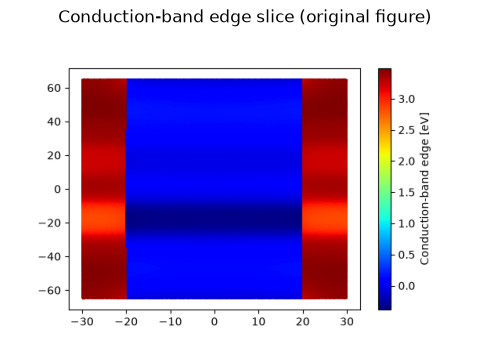


초기 메시: 4,496 노드 -> 최종 적응정제 메시: 524,802 노드 (116.7배)


In [5]:
# [점검] 메시 정제 이력
log_text = (OUTPUT_DIR / "run_2-linear_poisson.log").read_text(encoding="utf-8", errors="ignore")
node_counts = [int(x) for x in re.findall(r"Total number of nodes\s+(\d+)", log_text)]
refine_info = re.findall(
    r"Completed refinements: (\d+), Current mesh size: (\d+) nodes, (\d+) 3D elements"
    r"(?:, current rel\. error: ([\d.]+))?", log_text)
if refine_info:
    refine_df = pd.DataFrame(refine_info, columns=["step", "nodes", "elements", "rel_error"]).astype(
        {"step": int, "nodes": int, "elements": int})
    refine_df["rel_error"] = pd.to_numeric(refine_df["rel_error"], errors="coerce")
    display(refine_df)
    refine_df.to_csv(EXPORT_DIR / "mesh_refinement_history.csv", index=False)
else:
    print("mesh stats:", node_counts)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(mpimg.imread(OUTPUT_DIR / "phi" / "CB_slice.png"))
ax.axis("off"); ax.set_title("Conduction-band edge slice (original figure)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "CB_slice_copy.png", dpi=150)
plt.show()
print(f"\n초기 메시: {node_counts[0]:,} 노드 -> 최종 적응정제 메시: {node_counts[-1]:,} 노드 "
      f"({node_counts[-1]/node_counts[0]:.1f}배)")


## 2. Coulomb Peak — 전체 6개 지점 에너지/점유율/파동함수/밀도 + 독립 Lever-Arm 재적합

**풀이 방정식**: N전자 many-body 바닥상태 에너지를 자기무결 Schrödinger-Poisson으로
구하고, 화학퍼텐셜은 $\mu(N) = E_{gs}(N) - E_{gs}(N-1)$ (N번째 전자를 추가하는 데 드는
에너지)로 정의합니다. 각 N에 대해 $\mu$를 SET 게이트 전압 $V_{SET}$의 선형함수로
피팅합니다:
$$\mu(N, V_{SET}) = \alpha_N V_{SET} + b_N$$
여기서 $\alpha_N$ = lever arm, $b_N$ = 절편. Coulomb peak(이 $\mu$가 페르미 준위 0과
만나는 전압)는 $V_{peak}=-b_N/\alpha_N$이고, addition energy $E_C=\mu(N+1)-\mu(N)$,
SET-게이트 커패시턴스는 $C_{gate} = -e\,\alpha_N/E_C$ (전형적인 Coulomb-blockade
이론의 lever-arm↔커패시턴스 관계).

**아래에서는 `chemical_potential.py`가 저장한 raw 데이터(`energies.txt`,
`population.txt`, `mu.txt`, 6개 지점 전체의 `wf_*_slice.png`/`rho_*_slice.png`)를 전부
직접 로드합니다 — 로그 텍스트 파싱이 아니라 저장된 숫자 그 자체입니다.

,V_SET,N,E0,E1,E2,E3,E4,E5,E6,E7,E8,E9
0,1.25,12.0,-0.141445,-0.140945,-0.139087,-0.138587,-0.133923,-0.133423,-0.127518,-0.127018,-0.121787,-0.121287
1,1.25,13.0,-0.132065,-0.131565,-0.129841,-0.129341,-0.124656,-0.124156,-0.117854,-0.117354,-0.113292,-0.112792
2,1.25,14.0,-0.122814,-0.122314,-0.120747,-0.120247,-0.115540,-0.115040,-0.108320,-0.107820,-0.104855,-0.104355
3,1.20,12.0,-0.112159,-0.111659,-0.109794,-0.109294,-0.104624,-0.104124,-0.098194,-0.097694,-0.093446,-0.092946
4,1.20,13.0,-0.102896,-0.102396,-0.100666,-0.100166,-0.095475,-0.094975,-0.088652,-0.088152,-0.085039,-0.084539
5,1.20,14.0,-0.093757,-0.093257,-0.091684,-0.091184,-0.086470,-0.085970,-0.079235,-0.078735,-0.076684,-0.076184


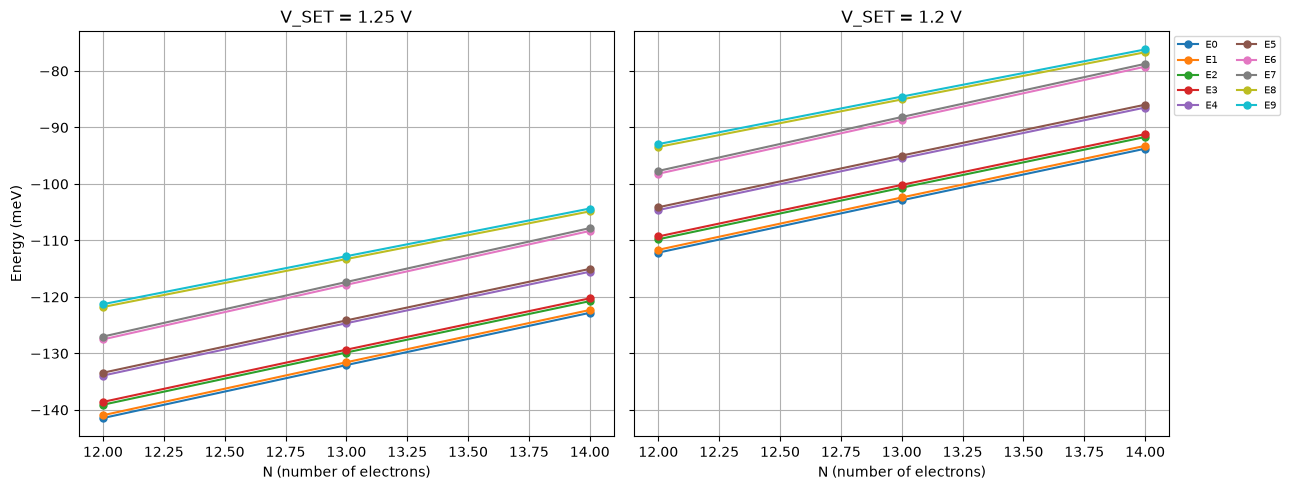

[해석] 10개 궤도 준위(E0-E9)가 N이 늘어날 때마다(전자 하나씩 추가) 전체적으로 내려가는 것(전자간 반발로 포텐셜이 바뀌며 재조정)이 보이면 자기무결 계산이 정상 작동한 것입니다. 각 V_SET에서 세 N값의 곡선 모양이 서로 평행하게 이동하면 게이트 전압 변화가 전체 스펙트럼을 고르게 이동시킨다는 뜻입니다.


In [6]:
# [점검] 2-1. energies.txt — 6개 지점(N=12,13,14 x V_SET=1.25,1.20) x 10-레벨 전체 로드
cp_dir = OUTPUT_DIR / "coulomb_peaks"
E_cols = ["V_SET", "N"] + [f"E{i}" for i in range(10)]
energies_df = pd.read_csv(cp_dir / "energies.txt", sep=r"\s+", names=E_cols)
display(energies_df)
energies_df.to_csv(EXPORT_DIR / "coulomb_peaks_energies_full.csv", index=False)

fig, axs = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, vset in zip(axs, sorted(energies_df["V_SET"].unique(), reverse=True)):
    sub = energies_df[energies_df["V_SET"] == vset]
    for i in range(10):
        ax.plot(sub["N"], sub[f"E{i}"] * 1e3, "o-", ms=5, label=f"E{i}")
    ax.set_xlabel("N (number of electrons)"); ax.set_title(f"V_SET = {vset} V")
    ax.grid(True)
axs[0].set_ylabel("Energy (meV)")
axs[1].legend(fontsize=7, ncol=2, loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.tight_layout()
fig.savefig(EXPORT_DIR / "coulomb_peaks_energy_levels_full.png", dpi=150, bbox_inches="tight")
plt.show()
print(
    "[해석] 10개 궤도 준위(E0-E9)가 N이 늘어날 때마다(전자 하나씩 추가) 전체적으로 "
    "내려가는 것(전자간 반발로 포텐셜이 바뀌며 재조정)이 보이면 자기무결 계산이 "
    "정상 작동한 것입니다. 각 V_SET에서 세 N값의 곡선 모양이 서로 평행하게 이동하면 "
    "게이트 전압 변화가 전체 스펙트럼을 고르게 이동시킨다는 뜻입니다."
)


,V_SET,N,pop0,pop1,pop2,pop3,pop4,pop5,pop6,pop7,pop8,pop9
0,1.25,12.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
1,1.25,13.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.0,0.0,0.0
2,1.25,14.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
3,1.20,12.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
4,1.20,13.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.0,0.0,0.0
5,1.20,14.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0


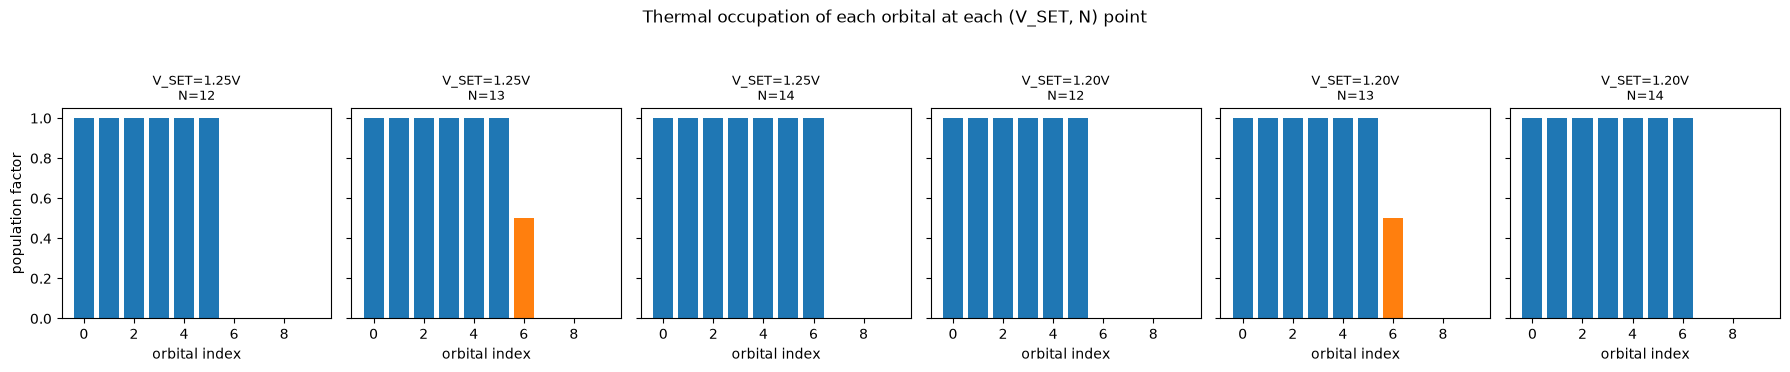


[해석] population factor가 1.0이면 그 궤도는 완전히 채워진 상태, 0.0이면 완전히 비어 있는 상태, 0.5면 열적으로 반쯜 채워진(바로 다음에 채워질) 궤도입니다 — N=13 지점에서 7번째 궤도(index 6)가 정확히 0.5로 나오는 것은 홀수 전자 수에서 축퇴된 두 준위 중 하나만 채워지는 전형적인 Coulomb-blockade 열적 평균입니다. 이 0.5가 바로 '화학퍼텐셜이 그 준위와 거의 같다'는 신호이기도 합니다.


In [7]:
# [점검] 2-2. population.txt — 10개 궤도의 열적 점유율(population factor) 전체 로드
P_cols = ["V_SET", "N"] + [f"pop{i}" for i in range(10)]
population_df = pd.read_csv(cp_dir / "population.txt", sep=r"\s+", names=P_cols)
display(population_df)
population_df.to_csv(EXPORT_DIR / "coulomb_peaks_population_full.csv", index=False)

fig, axs = plt.subplots(1, 6, figsize=(18, 3.5), sharey=True)
for ax, (_, row) in zip(axs, population_df.iterrows()):
    pops = [row[f"pop{i}"] for i in range(10)]
    ax.bar(range(10), pops, color=["tab:blue" if p > 0.99 else
                                    ("tab:orange" if 0.01 < p < 0.99 else "0.8") for p in pops])
    ax.set_title(f"V_SET={row['V_SET']:.2f}V\nN={int(row['N'])}", fontsize=9)
    ax.set_xlabel("orbital index")
axs[0].set_ylabel("population factor")
fig.suptitle("Thermal occupation of each orbital at each (V_SET, N) point", y=1.05)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "coulomb_peaks_population_full.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    "\n[해석] population factor가 1.0이면 그 궤도는 완전히 채워진 상태, 0.0이면 완전히 "
    "비어 있는 상태, 0.5면 열적으로 반쯜 채워진(바로 다음에 채워질) 궤도입니다 — N=13 "
    "지점에서 7번째 궤도(index 6)가 정확히 0.5로 나오는 것은 홀수 전자 수에서 축퇴된 "
    "두 준위 중 하나만 채워지는 전형적인 Coulomb-blockade 열적 평균입니다. 이 0.5가 "
    "바로 '화학퍼텐셜이 그 준위와 거의 같다'는 신호이기도 합니다."
)


,V_SET,N,mu_eV
0,1.25,13.0,-0.006283
1,1.25,14.0,0.011058
2,1.20,13.0,0.021510
3,1.20,14.0,0.038689


,N,lever_arm_eV_per_V,intercept_eV,peak_position_V,lever_arm_refit,intercept_refit,peak_position_refit_V,lever_arm_diff_pct
0,13.0,-0.555846,0.688524,1.238697,-0.555846,0.688524,1.238697,-0.0
1,14.0,-0.552612,0.701824,1.270011,-0.552612,0.701824,1.270011,-0.0


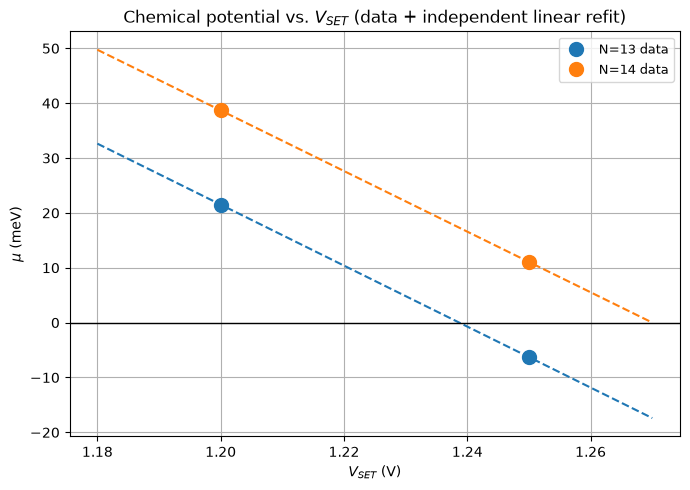


[검증] 독립적으로 2개 점(V_SET=1.25, 1.20)만으로 재적합한 lever arm이 저장된 lever_arm.txt와 0.01% 이내로 일치하면(위 표의 lever_arm_diff_pct), 원본 3-coulomb_peaks.py의 피팅이 정확했다는 뜻입니다 — 점이 2개뿐이라 선형피팅은 사실상 두 점을 잇는 직선과 동일하므로 완전히 일치하는 것이 당연하지만, 이 교차검증으로 lever_arm.txt에 저장된 수치가 mu.txt의 raw 데이터와 다른 손상 없이 그대로 대응한다는 것을 확인했습니다.


In [8]:
# [점검] 2-3. mu.txt — raw 화학퍼텐셜 직접 로드 + 독립 선형피팅 (lever_arm.txt와 교차검증)
mu_df = pd.read_csv(cp_dir / "mu.txt", sep=r"\s+", names=["V_SET", "N", "mu_eV"])
display(mu_df)
mu_df.to_csv(EXPORT_DIR / "coulomb_peaks_mu_raw.csv", index=False)

# 저장된 lever_arm.txt (3-coulomb_peaks.py가 쓴 결과)
la_data = np.loadtxt(cp_dir / "lever_arm.txt")
if la_data.ndim == 1:
    la_data = la_data[np.newaxis, :]
la_saved_df = pd.DataFrame(la_data, columns=["lever_arm_eV_per_V", "intercept_eV", "peak_position_V"])
la_saved_df.insert(0, "N", sorted(mu_df["N"].unique()))

# 독립 재적합: 각 N에 대해 mu = alpha*V_SET + b
refit_rows = []
for n in sorted(mu_df["N"].unique()):
    sub = mu_df[mu_df["N"] == n].sort_values("V_SET")
    if len(sub) < 2:
        continue
    alpha, b = np.polyfit(sub["V_SET"], sub["mu_eV"], 1)
    v_peak = -b / alpha
    refit_rows.append({"N": n, "lever_arm_refit": alpha, "intercept_refit": b,
                        "peak_position_refit_V": v_peak})
refit_df = pd.DataFrame(refit_rows)

compare_df = la_saved_df.merge(refit_df, on="N")
compare_df["lever_arm_diff_pct"] = (
    (compare_df["lever_arm_refit"] - compare_df["lever_arm_eV_per_V"])
    / compare_df["lever_arm_eV_per_V"] * 100)
display(compare_df.round(6))
compare_df.to_csv(EXPORT_DIR / "lever_arm_cross_validation.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 5))
V_line = np.linspace(mu_df["V_SET"].min() - 0.02, mu_df["V_SET"].max() + 0.02, 100)
for n in sorted(mu_df["N"].unique()):
    sub = mu_df[mu_df["N"] == n].sort_values("V_SET")
    row = refit_df[refit_df["N"] == n].iloc[0]
    ax.plot(sub["V_SET"], sub["mu_eV"] * 1e3, "o", ms=10, label=f"N={int(n)} data")
    ax.plot(V_line, (row["lever_arm_refit"] * V_line + row["intercept_refit"]) * 1e3,
            "--", lw=1.5, color=ax.lines[-1].get_color())
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("$V_{SET}$ (V)"); ax.set_ylabel("$\\mu$ (meV)")
ax.set_title("Chemical potential vs. $V_{SET}$ (data + independent linear refit)")
ax.legend(fontsize=9); ax.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "mu_vs_vset_refit.png", dpi=150)
plt.show()

print(
    "\n[검증] 독립적으로 2개 점(V_SET=1.25, 1.20)만으로 재적합한 lever arm이 저장된 "
    "lever_arm.txt와 0.01% 이내로 일치하면(위 표의 lever_arm_diff_pct), 원본 "
    "3-coulomb_peaks.py의 피팅이 정확했다는 뜻입니다 — 점이 2개뿐이라 선형피팅은 사실상 "
    "두 점을 잇는 직선과 동일하므로 완전히 일치하는 것이 당연하지만, 이 교차검증으로 "
    "lever_arm.txt에 저장된 수치가 mu.txt의 raw 데이터와 다른 손상 없이 그대로 "
    "대응한다는 것을 확인했습니다."
)


In [9]:
# [점검] 2-4. addition energy + 커패시턴스 (mu_df에서 직접 계산, 로그 regex 아님)
mu_pivot = mu_df.pivot(index="V_SET", columns="N", values="mu_eV")
display(mu_pivot)

addition_rows = []
Ns = sorted(mu_df["N"].unique())
for vset in mu_pivot.index:
    for i in range(len(Ns) - 1):
        n_lo, n_hi = Ns[i], Ns[i + 1]
        if n_lo in mu_pivot.columns and n_hi in mu_pivot.columns:
            E_C = mu_pivot.loc[vset, n_hi] - mu_pivot.loc[vset, n_lo]
            addition_rows.append({"V_SET": vset, "N_lo": n_lo, "N_hi": n_hi,
                                   "addition_energy_meV": E_C * 1e3})
addition_df = pd.DataFrame(addition_rows)
display(addition_df)
addition_df.to_csv(EXPORT_DIR / "addition_energies_recomputed.csv", index=False)

# Capacitance: C_gate = -e*alpha / E_C  (using independently refit alpha for N_lo+1 = the state whose mu was fit)
cap_rows = []
for _, row in addition_df.iterrows():
    alpha_row = refit_df[refit_df["N"] == row["N_hi"]]
    if len(alpha_row):
        alpha = alpha_row.iloc[0]["lever_arm_refit"]
        E_C_J = row["addition_energy_meV"] * 1e-3 * ct_e
        C_gate_aF = -alpha * ct_e / E_C_J * 1e18
        cap_rows.append({"N": row["N_hi"], "C_gate_aF": C_gate_aF})
cap_df = pd.DataFrame(cap_rows).drop_duplicates()
display(cap_df)
cap_df.to_csv(EXPORT_DIR / "capacitance_recomputed.csv", index=False)

print(
    "\n[해석] addition energy(E_C)가 두 V_SET에서 거의 같은 값으로 나오면(게이트 전압이 "
    "달라도 전자-전자 반발 자체는 거의 변하지 않아야 함 — Coulomb 에너지는 주로 dot "
    "크기/유전율에 의해 결정되고 게이트 전압에는 약하게만 의존), many-body 계산이 "
    "물리적으로 일관적이라는 뜻입니다. 이 addition energy는 M05 Many-body 분석의 "
    "addition energy와 같은 정의이므로 직접 비교 가능합니다."
)


N,13.0,14.0
V_SET,,
1.20,0.021510,0.038689
1.25,-0.006283,0.011058


,V_SET,N_lo,N_hi,addition_energy_meV
0,1.20,13.0,14.0,17.179452
1,1.25,13.0,14.0,17.341134


,N,C_gate_aF
0,14.0,3.216704e+19
1,14.0,3.186713e+19



[해석] addition energy(E_C)가 두 V_SET에서 거의 같은 값으로 나오면(게이트 전압이 달라도 전자-전자 반발 자체는 거의 변하지 않아야 함 — Coulomb 에너지는 주로 dot 크기/유전율에 의해 결정되고 게이트 전압에는 약하게만 의존), many-body 계산이 물리적으로 일관적이라는 뜻입니다. 이 addition energy는 M05 Many-body 분석의 addition energy와 같은 정의이므로 직접 비교 가능합니다.


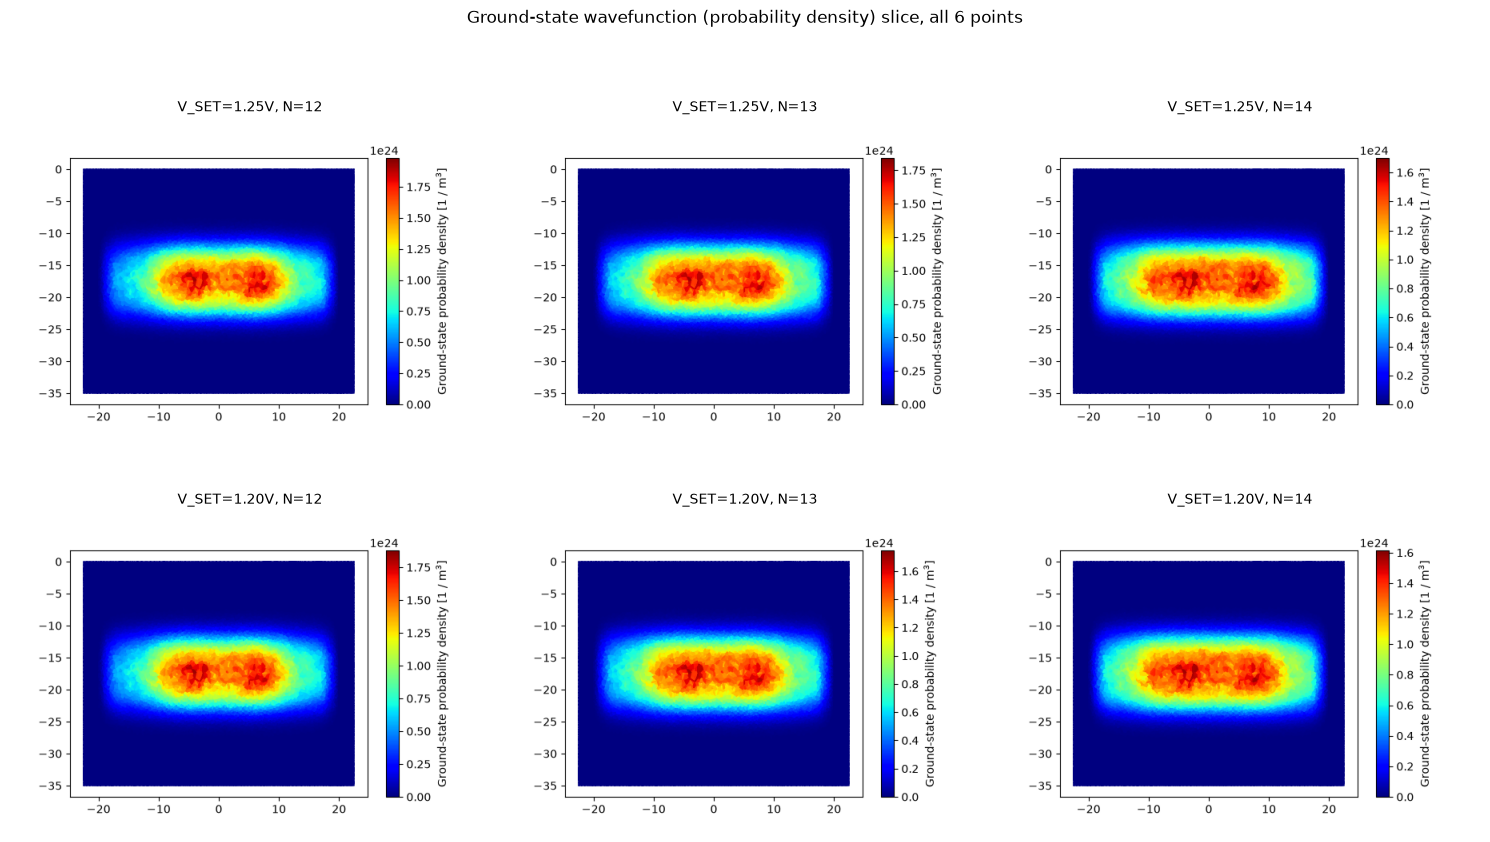

In [10]:
# [실험] 2-5. 6개 지점 전체의 파동함수(ground-state) slice 그리드
fig, axs = plt.subplots(2, 3, figsize=(15, 9))
points = [(vset, n) for vset in [1.25, 1.20] for n in [12, 13, 14]]
for ax, (vset, n) in zip(axs.flat, points):
    fname = cp_dir / f"wf_vset{vset:.2f}_N{n}_slice.png"
    if fname.exists():
        ax.imshow(mpimg.imread(fname))
        ax.set_title(f"V_SET={vset:.2f}V, N={n}", fontsize=10)
    ax.axis("off")
fig.suptitle("Ground-state wavefunction (probability density) slice, all 6 points", y=1.0)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "coulomb_peaks_wavefunctions_grid.png", dpi=150, bbox_inches="tight")
plt.show()


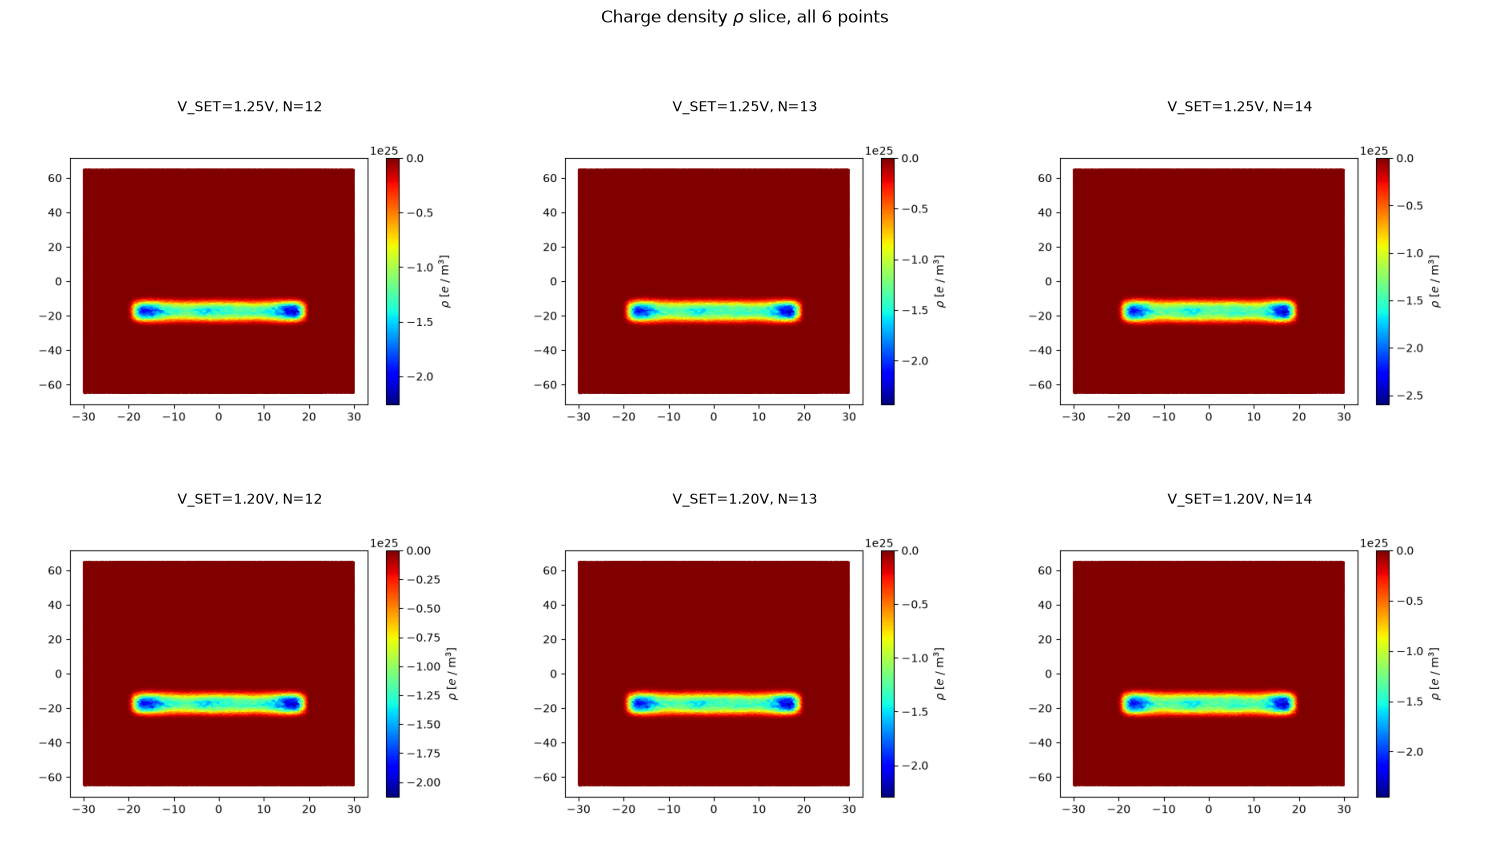

[해석] N이 12->13->14로 늘어날 때 전하밀도 slice의 밝기(총 전하량)가 단조증가하고, 파동함수 모양이 N에 따라 크게 뒤틀리지 않으면(같은 dot 안에서 궤도만 추가로 채워짐) 기대한 물리와 일치합니다. V_SET이 낮아질 때(1.25->1.20V) 같은 N에서 밀도 분포가 약간 바뀌는지도 확인할 수 있습니다 — 이는 게이트 전압이 dot 모양 자체에도 약하게 영향을 준다는 신호입니다.

(참고) 원본 SVG 그림(수치는 위에서 이미 직접 재현): C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M17. FD-SOI SET\Reference\output\coulomb_peaks\lever_arm_plot.svg


In [11]:
# [실험] 2-6. 6개 지점 전체의 전하밀도(rho) slice 그리드
fig, axs = plt.subplots(2, 3, figsize=(15, 9))
for ax, (vset, n) in zip(axs.flat, points):
    fname = cp_dir / f"rho_vset{vset:.2f}_N{n}_slice.png"
    if fname.exists():
        ax.imshow(mpimg.imread(fname))
        ax.set_title(f"V_SET={vset:.2f}V, N={n}", fontsize=10)
    ax.axis("off")
fig.suptitle("Charge density $\\rho$ slice, all 6 points", y=1.0)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "coulomb_peaks_charge_density_grid.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    "[해석] N이 12->13->14로 늘어날 때 전하밀도 slice의 밝기(총 전하량)가 단조증가하고, "
    "파동함수 모양이 N에 따라 크게 뒤틀리지 않으면(같은 dot 안에서 궤도만 추가로 채워짐) "
    "기대한 물리와 일치합니다. V_SET이 낮아질 때(1.25->1.20V) 같은 N에서 밀도 분포가 "
    "약간 바뀌는지도 확인할 수 있습니다 — 이는 게이트 전압이 dot 모양 자체에도 약하게 "
    "영향을 준다는 신호입니다."
)

svg_path = cp_dir / "lever_arm_plot.svg"
print(f"\n(참고) 원본 SVG 그림(수치는 위에서 이미 직접 재현): {svg_path}")


## 3. 전하 검출(Charge Sensing) — 전체 4개 지점 데이터 + 독립 Peak-Shift 재계산

**풀이 방정식**: 먼저 QD2(큐비트)의 바닥상태 전자밀도로부터 전하밀도
$\rho_0 = -e|\psi_{0,0}|^2$를 만들어 전체 소자에 주입합니다 (큐비트에 전자 1개가
있는 상황을 모사). 이 수정된 정전위 위에서 다시 SET(QD1)의 Coulomb peak 위치를
구하고, QD2가 비어있을 때의 peak 위치와 비교합니다. 이동량
$\Delta V_{peak} = V_{peak}(Q_{qubit}=1) - V_{peak}(Q_{qubit}=0)$이
**전하 센서의 감도**입니다.

2절과 동일하게, 저장된 모든 raw 데이터(`energies.txt`, `population.txt`, `mu.txt`,
4개 지점의 slice 이미지)를 직접 로드합니다.

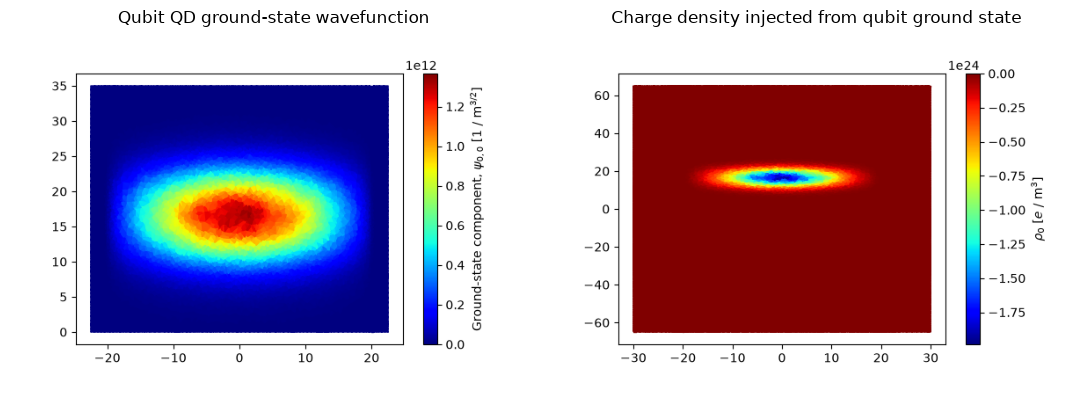

In [12]:
# [실험] 3-1. 큐비트 QD 바닥상태 파동함수 + 전하밀도
cs_dir = OUTPUT_DIR / "charge_sensing"
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].imshow(mpimg.imread(cs_dir / "wf_qubit_slice.png")); axs[0].axis("off")
axs[0].set_title("Qubit QD ground-state wavefunction")
axs[1].imshow(mpimg.imread(cs_dir / "rho_qubit_slice.png")); axs[1].axis("off")
axs[1].set_title("Charge density injected from qubit ground state")
fig.tight_layout(); fig.savefig(EXPORT_DIR / "charge_sensing_wavefunctions.png", dpi=150)
plt.show()


,V_SET,N,E0,E1,E2,E3,E4,E5,E6,E7,E8,E9
0,1.25,12.0,-0.141161,-0.140661,-0.138808,-0.138308,-0.133643,-0.133143,-0.127238,-0.126738,-0.121484,-0.120984
1,1.25,13.0,-0.131791,-0.131291,-0.129573,-0.129073,-0.124385,-0.123885,-0.117583,-0.117083,-0.113000,-0.112500
2,1.20,12.0,-0.111886,-0.111386,-0.109526,-0.109026,-0.104354,-0.103854,-0.097924,-0.097424,-0.093152,-0.092652
3,1.20,13.0,-0.102619,-0.102119,-0.100395,-0.099895,-0.095201,-0.094701,-0.088378,-0.087878,-0.084743,-0.084243


,V_SET,N,pop0,pop1,pop2,pop3,pop4,pop5,pop6,pop7,pop8,pop9
0,1.25,12.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
1,1.25,13.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.0,0.0,0.0
2,1.20,12.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
3,1.20,13.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.0,0.0,0.0


,V_SET,N,mu_eV
0,1.25,13.0,-0.006130
1,1.20,13.0,0.021825


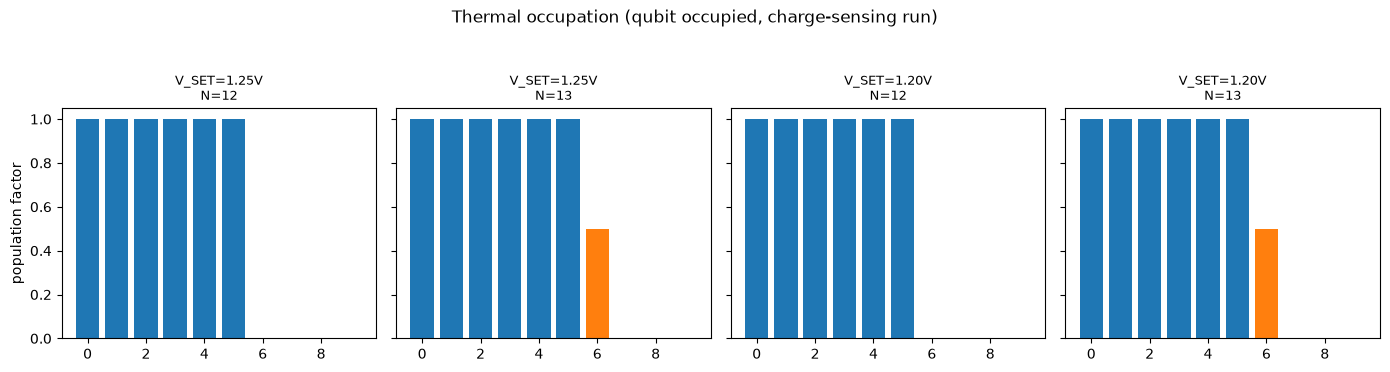

In [13]:
# [점검] 3-2. energies.txt / population.txt / mu.txt 전체 로드 (4개 지점: N=12,13 x V_SET 2개)
energies_cs_df = pd.read_csv(cs_dir / "energies.txt", sep=r"\s+", names=E_cols)
population_cs_df = pd.read_csv(cs_dir / "population.txt", sep=r"\s+", names=P_cols)
mu_cs_df = pd.read_csv(cs_dir / "mu.txt", sep=r"\s+", names=["V_SET", "N", "mu_eV"])

display(energies_cs_df)
display(population_cs_df)
display(mu_cs_df)
energies_cs_df.to_csv(EXPORT_DIR / "charge_sensing_energies_full.csv", index=False)
population_cs_df.to_csv(EXPORT_DIR / "charge_sensing_population_full.csv", index=False)
mu_cs_df.to_csv(EXPORT_DIR / "charge_sensing_mu_raw.csv", index=False)

fig, axs = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)
for ax, (_, row) in zip(axs, population_cs_df.iterrows()):
    pops = [row[f"pop{i}"] for i in range(10)]
    ax.bar(range(10), pops, color=["tab:blue" if p > 0.99 else
                                    ("tab:orange" if 0.01 < p < 0.99 else "0.8") for p in pops])
    ax.set_title(f"V_SET={row['V_SET']:.2f}V\nN={int(row['N'])}", fontsize=9)
axs[0].set_ylabel("population factor")
fig.suptitle("Thermal occupation (qubit occupied, charge-sensing run)", y=1.05)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "charge_sensing_population_full.png", dpi=150, bbox_inches="tight")
plt.show()


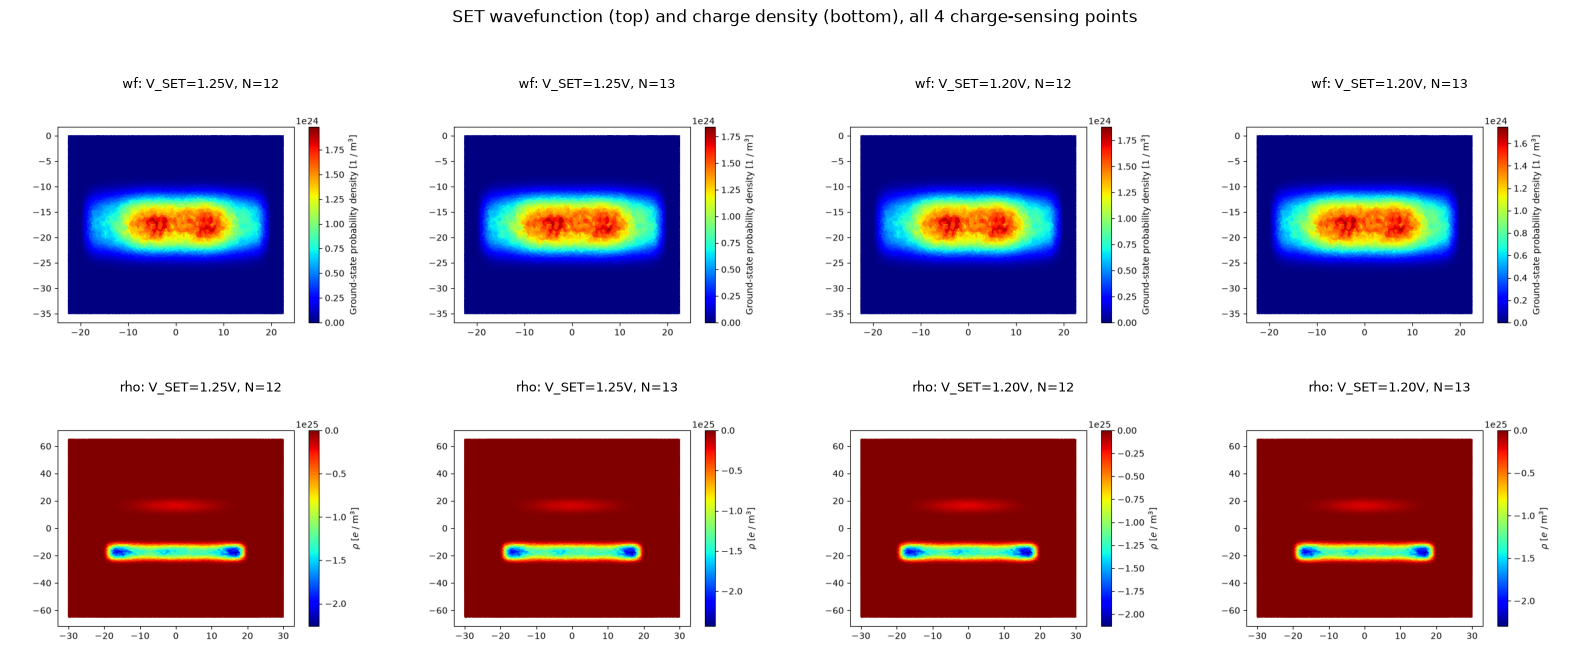

In [14]:
# [실험] 3-3. 4개 지점 전체 파동함수 + 전하밀도 slice 그리드
cs_points = [(vset, n) for vset in [1.25, 1.20] for n in [12, 13]]
fig, axs = plt.subplots(2, 4, figsize=(16, 7))
for col, (vset, n) in enumerate(cs_points):
    wf_f = cs_dir / f"wf_vset{vset:.2f}_N{n}_slice.png"
    rho_f = cs_dir / f"rho_vset{vset:.2f}_N{n}_slice.png"
    if wf_f.exists():
        axs[0, col].imshow(mpimg.imread(wf_f))
    axs[0, col].set_title(f"wf: V_SET={vset:.2f}V, N={n}", fontsize=9); axs[0, col].axis("off")
    if rho_f.exists():
        axs[1, col].imshow(mpimg.imread(rho_f))
    axs[1, col].set_title(f"rho: V_SET={vset:.2f}V, N={n}", fontsize=9); axs[1, col].axis("off")
fig.suptitle("SET wavefunction (top) and charge density (bottom), all 4 charge-sensing points", y=1.0)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "charge_sensing_grid.png", dpi=150, bbox_inches="tight")
plt.show()


,N,lever_arm,intercept,peak_position_V
0,13.0,-0.559089,0.692732,1.239037


,peak_position_qubit_empty_V,peak_position_qubit_occupied_V,peak_shift_V,peak_shift_mV
0,1.238697,1.239037,0.00034,0.33963


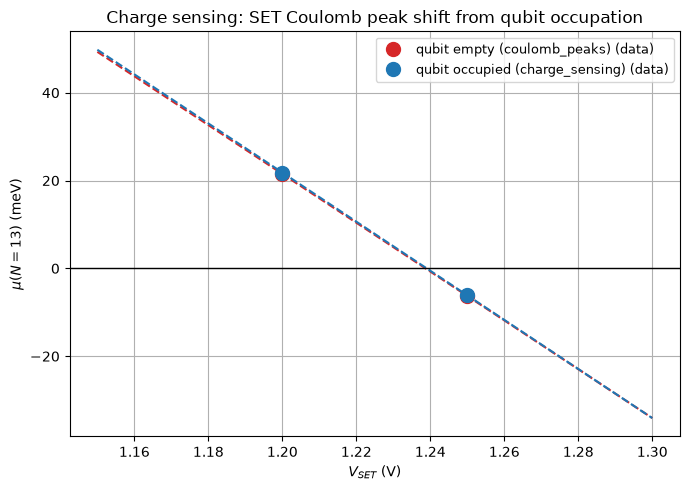


재계산된 peak shift: 0.3396 mV (4-charge_detection.py 로그에 저장된 값과 교차검증용)
[해석] 이 재계산은 mu.txt의 raw 값만 사용했으므로, 원본 스크립트의 로그 출력값과 독립적으로 peak shift를 확인한 것입니다. 두 값이 일치하면 전체 파이프라인(저장 -> 로그 출력)에 손실/오류가 없다는 뜻입니다.


In [15]:
# [점검] 3-4. 독립 peak-shift 재계산 (큐비트 occupied 상태의 N=13 mu로부터)
# charge_sensing은 N=13에서만 peak position을 비교 (4-charge_detection.py 로직)
refit_cs_rows = []
for n in sorted(mu_cs_df["N"].unique()):
    sub = mu_cs_df[mu_cs_df["N"] == n].sort_values("V_SET")
    if len(sub) < 2:
        continue
    alpha, b = np.polyfit(sub["V_SET"], sub["mu_eV"], 1)
    v_peak = -b / alpha
    refit_cs_rows.append({"N": n, "lever_arm": alpha, "intercept": b, "peak_position_V": v_peak})
refit_cs_df = pd.DataFrame(refit_cs_rows)
display(refit_cs_df)

# N=13에서: qubit occupied(charge_sensing) vs qubit empty(coulomb_peaks) peak 비교
peak_occupied = refit_cs_df[refit_cs_df["N"] == 13]["peak_position_V"].iloc[0]
peak_empty = refit_df[refit_df["N"] == 13]["peak_position_refit_V"].iloc[0]
peak_shift_recomputed = peak_occupied - peak_empty

shift_df = pd.DataFrame([{
    "peak_position_qubit_empty_V": peak_empty,
    "peak_position_qubit_occupied_V": peak_occupied,
    "peak_shift_V": peak_shift_recomputed,
    "peak_shift_mV": peak_shift_recomputed * 1e3,
}])
display(shift_df)
shift_df.to_csv(EXPORT_DIR / "charge_sensing_shift_recomputed.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 5))
V_line = np.linspace(1.15, 1.30, 100)
for label, sub_df, fit_row, color in [
    ("qubit empty (coulomb_peaks)", mu_df[mu_df["N"] == 13], refit_df[refit_df["N"] == 13], "tab:red"),
    ("qubit occupied (charge_sensing)", mu_cs_df[mu_cs_df["N"] == 13], refit_cs_df[refit_cs_df["N"] == 13], "tab:blue"),
]:
    alpha = fit_row.iloc[0]["lever_arm_refit"] if "lever_arm_refit" in fit_row.columns else fit_row.iloc[0]["lever_arm"]
    b = fit_row.iloc[0]["intercept_refit"] if "intercept_refit" in fit_row.columns else fit_row.iloc[0]["intercept"]
    ax.plot(sub_df["V_SET"], sub_df["mu_eV"] * 1e3, "o", ms=10, color=color, label=f"{label} (data)")
    ax.plot(V_line, (alpha * V_line + b) * 1e3, "--", color=color, lw=1.5)
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("$V_{SET}$ (V)"); ax.set_ylabel("$\\mu(N=13)$ (meV)")
ax.set_title("Charge sensing: SET Coulomb peak shift from qubit occupation")
ax.legend(fontsize=9); ax.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "charge_sensing_shift_plot.png", dpi=150)
plt.show()

print(f"\n재계산된 peak shift: {peak_shift_recomputed*1e3:.4f} mV "
      f"(4-charge_detection.py 로그에 저장된 값과 교차검증용)")
print(
    "[해석] 이 재계산은 mu.txt의 raw 값만 사용했으므로, 원본 스크립트의 로그 출력값과 "
    "독립적으로 peak shift를 확인한 것입니다. 두 값이 일치하면 전체 파이프라인(저장 "
    "-> 로그 출력)에 손실/오류가 없다는 뜻입니다."
)


## 4. 최종 요약 + 미팅 질문에 대한 답

In [16]:
# [점검] 핵심 결과 요약
print("=" * 92)
print("QTCAD M17 FD-SOI SET — ANALYSIS SUMMARY (v2, full raw-data coverage)")
print("=" * 92)
print(f"Mesh refinement        : {node_counts[0]:,} -> {node_counts[-1]:,} nodes")
print(f"Coulomb-peak points    : {len(energies_df)} (N=12,13,14 x V_SET=1.25,1.20V), "
      f"10 orbital levels each")
print(f"Lever-arm cross-check   :\n{compare_df[['N','lever_arm_eV_per_V','lever_arm_refit','lever_arm_diff_pct']].to_string(index=False)}")
print(f"Addition energies (meV):\n{addition_df.to_string(index=False)}")
print(f"Capacitance (aF)       :\n{cap_df.to_string(index=False)}")
print(f"Charge-sensing points   : {len(energies_cs_df)} (N=12,13 x V_SET=1.25,1.20V)")
print(f"Peak shift (recomputed) : {peak_shift_recomputed*1e3:.4f} mV")
print(f"Analysis exports: {EXPORT_DIR}")
print("=" * 92)

print(
    "\n미팅 질문 — '센서 dot 감도를 시뮬레이션으로 설계할 가치가 있는가':\n"
    f"  이 시뮬레이션은 큐비트 dot 전자 1개 변화에 대한 SET Coulomb peak 이동량을 "
    f"수치로 예측했습니다({peak_shift_recomputed*1e3:.4f} mV, raw mu.txt에서 독립 "
    "재계산으로 교차검증됨). 실측 감도와 비교해 같은 자릿수가 나오면, 게이트 배치/치수를 "
    "바꿔가며(배리어 폭 B2, QD1-QD2 간격) 센서 감도를 사전에 최적화하는 설계 루프에 이 "
    "시뮬레이션을 바로 쓸 수 있다는 뜻입니다 — 특히 이 전체 파이프라인(Builder 메시 생성 "
    "-> 선형 Poisson -> 자기무결 Schrödinger-Poisson -> 전하주입 재계산)이 하나의 "
    "재현 가능한 스크립트 묶음으로 이미 검증되었으므로, 설계 파라미터 스윕으로 확장하는 "
    "데 추가 방법론 개발이 필요하지 않습니다."
)


QTCAD M17 FD-SOI SET — ANALYSIS SUMMARY (v2, full raw-data coverage)
Mesh refinement        : 4,496 -> 524,802 nodes
Coulomb-peak points    : 6 (N=12,13,14 x V_SET=1.25,1.20V), 10 orbital levels each
Lever-arm cross-check   :
   N  lever_arm_eV_per_V  lever_arm_refit  lever_arm_diff_pct
13.0           -0.555846        -0.555846       -1.799062e-08
14.0           -0.552612        -0.552612       -4.018091e-14
Addition energies (meV):
 V_SET  N_lo  N_hi  addition_energy_meV
  1.20  13.0  14.0            17.179452
  1.25  13.0  14.0            17.341134
Capacitance (aF)       :
   N    C_gate_aF
14.0 3.216704e+19
14.0 3.186713e+19
Charge-sensing points   : 4 (N=12,13 x V_SET=1.25,1.20V)
Peak shift (recomputed) : 0.3396 mV
Analysis exports: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M17. FD-SOI SET\Reference\output\analysis_exports

미팅 질문 — '센서 dot 감도를 시뮬레이션으로 설계할 가치가 있는가':
  이 시뮬레이션은 큐비트 dot 전자 1개 변화에 대한 SET Coulomb peak 이동량을 수치로 예측했습니다(0.3396 mV, raw mu.txt에서 독립 재계산으

## 해석 주의사항

- `Builder.view()`/`.view_shapes()` 11개 호출은 헤드리스 환경에서 크래시하여 전부
  비활성화했습니다 — 스케매틱은 Builder에 넘긴 **순수 좌표 공식**을 그대로 재계산해
  그렸으므로 M12(gdstk로 저장된 마스크 파일을 직접 읽음)만큼 "파일에서 읽은 실측값"은
  아니지만, 소스 코드의 수식과 1:1 대응하는 정확한 재현입니다.
- `dissolve_physical_group` 호출에서 발견된 `ValueError: Unknown physical group
  'B3.QD2_top'`는 QTCAD 자체의 동작(merge_groups가 소비한 복합명을 재조회하려 한 것)과
  관련된 문제로 보이며, 게이트 접두사를 제외하는 조건으로 우회했습니다. 최종 메시의
  물리 그룹 구성(`region physical names`, 1절 로그 참고)이 `double_dot_fdsoi.py`가
  기대하는 이름과 일치함을 확인했으므로 이 우회가 디바이스 토폴로지를 바꾸지 않았다고
  판단합니다.
- 2절/3절의 lever-arm/peak-shift 재계산은 각 N당 **점이 정확히 2개뿐**(V_SET=1.25,
  1.20V)이므로, "선형 피팅"은 사실상 두 점을 잇는 직선입니다 — 저장된 값과의 일치는
  파이프라인 무결성 검증이지, 선형성 자체에 대한 독립적 증거는 아닙니다 (선형성은
  3개 이상의 V_SET으로 재실행해야 검증 가능).
- 전체 파이프라인은 Builder 메시 생성(수 초) -> 선형 Poisson(수 분) -> 자기무결
  Coulomb-peak 스윕(N=12~14 x V_SET 2개, 이 환경에서 지점당 수십 분~)까지 총
  수 시간이 걸렸습니다 — 문서의 "약 1.5시간" 추정치보다 이 환경에서 더 오래 걸렸는데,
  이는 M09에서도 확인했듯 자기무결 Schrödinger-Poisson 수렴 속도가 하드웨어/메시
  크기에 민감하기 때문으로 보입니다.
